In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.patches import Polygon
import matplotlib.font_manager
import sunpy
import sunpy.map
from sunpy.coordinates import get_earth
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch,
                    ZScaleInterval)
import astropy.units as u
from ndcube import NDCube
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
from fancy_colorbar import wcs_scalebar

In [2]:
font_dirs = ["/cluster/home/zhuyin/scripts/fonts/helvetica"]  # The path to the custom font file.
font_files = matplotlib.font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    matplotlib.font_manager.fontManager.addfont(font_file)

In [3]:
ms_style_dict = {'axes.linewidth': 1.2,
                 'xtick.major.width': 0.8, 'xtick.major.size': 4,
                 'ytick.major.width': 0.8, 'ytick.major.size': 4,
                 'xtick.minor.width': 0.8, 'xtick.minor.size': 2,
                 'ytick.minor.width': 0.8, 'ytick.minor.size': 2,
                 'xtick.direction': 'out', 'ytick.direction': 'out',
                 'font.weight': 'light',
                 'font.sans-serif': 'Helvetica Neue',
                 'mathtext.fontset': 'custom',
                 'mathtext.rm' : 'Helvetica Neue'}

In [4]:
file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [5]:
file_hri_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/HRIEUV_pr.hdf5")
hri_pr_set = file_hri_pr_dset["hrieuv_img"]
hri_pr_da = da.from_array(hri_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))

hrieuv_date_ear = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])

In [6]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

target_wcs = dkist_vbi_target_cube_crop.wcs
target_wcs_rebin = dkist_vbi_target_cube_crop_rebin.wcs

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [7]:
hrieuv_index_ = 94
Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Hbeta_date_obs))

In [9]:
Hbeta_pr_set[Hbeta_index_].shape

(3840, 3840)

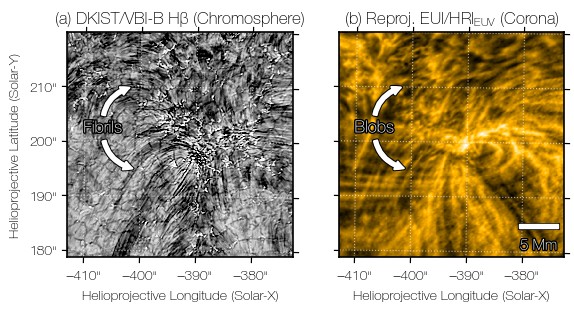

In [36]:
with plt.style.context(ms_style_dict):
    plt.close("all")
    fig = plt.figure(figsize=(6,3), layout="constrained")
    ax1 = fig.add_subplot(121, projection=unwrap_wcs_to_fitswcs(target_wcs)[0])
    ax1.imshow(Hbeta_pr_set[Hbeta_index_], cmap="Greys_r",
                norm=ImageNormalize(vmin=-0.05, vmax=1.5,
                stretch=AsinhStretch(0.6)),
                interpolation="none", aspect=1, rasterized=True)
    
    # ax1.set_axis_off()
    ax1.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)", weight="light")
    ax1.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)", weight="light")
    ax1.grid("on", lw=0.8, ls=":", color="white", alpha=0.6)
    ax1.set_title("(a) DKIST/VBI-B Hβ (Chromosphere)", weight="light")

    ax2 = fig.add_subplot(122, projection=unwrap_wcs_to_fitswcs(target_wcs_rebin)[0])
    ax2.imshow(hri_pr_set[hrieuv_index_],
                cmap="solar orbiterhri_euv174",
                interpolation="none", aspect=1,
                rasterized=True)
    
    ax2.coords[1].set_ticklabel_visible(False)
    ax2.coords[1].set_axislabel(" ", alpha=0)
    ax2.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)", weight="light")
    ax2.set_title(r"(b) Reproj. EUI/HRI$_{\rm EUV}$ (Corona)", weight="light")
    ax2.grid("on", lw=0.8, ls=":", color="white", alpha=0.6)

    sbA = wcs_scalebar(ax2, 5*u.Mm, corner="bottom left",
                label="5 Mm",
                dsun=get_earth(Hbeta_date_obs[Hbeta_index_]).radius,
                bbox_to_anchor=(0.8, 0.02, 0.15, 0.15),
                bbox_transform=ax2.transAxes,
                frame=False, 
                color="white", size_vertical=35/4,
                fontproperties={"size": 11},
                sep=8,
                pad=0,
                borderpad=0
                )
    
    fig.canvas.draw()
    
    sbA.txt_label._text.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])

    sbA.size_bar.get_children()[0].set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])

    ax1.annotate("Fibrils", xy=(1150, 1500),
    xytext=(600, 2200), color="white",
    arrowprops=dict(arrowstyle="simple",
    connectionstyle="arc3,rad=0.4",facecolor="w",
    edgecolor="w", lw=1.5,
    path_effects=[path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()]
    ),
    va="center", ha="center", fontsize=12,
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],)

    ax1.annotate("Fibrils", xy=(1100, 2900),
    xytext=(600, 2200), color="white",
    arrowprops=dict(arrowstyle="simple",
    connectionstyle="arc3,rad=-0.4",facecolor="w",
    edgecolor="w", lw=1.5,
    path_effects=[path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()]
    ),
    va="center", ha="center", fontsize=12,
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
    alpha=0)

    ax2.annotate("Blobs", xy=(1150/8, 1500/8),
    xytext=(600/8, 2200/8), color="white",
    arrowprops=dict(arrowstyle="simple",
    connectionstyle="arc3,rad=0.4",facecolor="w",
    edgecolor="w", lw=1.5,
    path_effects=[path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()]
    ),
    va="center", ha="center", fontsize=12,
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],)

    ax2.annotate("Blobs", xy=(1100/8, 2900/8),
    xytext=(600/8, 2200/8), color="white",
    arrowprops=dict(arrowstyle="simple",
    connectionstyle="arc3,rad=-0.4",facecolor="w",
    edgecolor="w", lw=1.5,
    path_effects=[path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()]
    ),
    va="center", ha="center", fontsize=12,
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
    alpha=0)

    fig.savefig("../../figs/test_figs/fibril_annual_report_2025.pdf", dpi=300, bbox_inches="tight")
    fig.savefig("../../figs/test_figs/fibril_annual_report_2025.png", dpi=300, bbox_inches="tight")
    plt.show()